# Multi-Tier Robustness of Accessibility (RoA) Evaluation
## Notebook 5/5 — Multi-Tier Analysis, Figure Generation & Hypothesis Testing

This notebook loads the pre-cached multi-tier simulation results (Level A, Level B1, Level B2, Level C) across the 336-hour hydrodynamic flood event, generates publication-ready figures (PDF/PNG), exports LaTeX tables for Chapter 5 of the research paper, and evaluates Hypotheses H1 and H2.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from css_geodata_service.robustness_of_accessibility.examples.notebooks.notebook_utils import (
    get_roa_cache_path,
    get_roa_hazard_areas_path,
    get_roa_outputs_path,
    RoaNotebookConfig,
)
from css_geodata_service.robustness_of_accessibility.utils.dynamic_roa import (
    load_or_compute_multi_tier_bundle,
)

cache_dir = get_roa_cache_path()
output_dir = get_roa_outputs_path()
paper_resources_dir = Path(r'C:\Users\WelJo\IdeaProjects\forschungspraktikum\paper\src\resources')
place_name = RoaNotebookConfig.place_name
safe_place = place_name.replace(' ', '_').replace(',', '')
print(f'Working with cached data in: {cache_dir}')

Working with cached data in: C:\Users\WelJo\IdeaProjects\forschungspraktikum\code\css_geodata_service\robustness_of_accessibility\data\processed


### 1. Load Pre-Calculated Multi-Tier Simulation Bundle

In [2]:
bundle = load_or_compute_multi_tier_bundle(
    cache_dir=cache_dir,
    place_name=place_name,
)

tiers = bundle['tiers']
hours = np.array(bundle['hours'])
print(f'Loaded multi-tier simulation bundle: {list(tiers.keys())} across {len(hours)} hours')

Loaded multi-tier simulation bundle: ['Level_A', 'Level_B1', 'Level_B2', 'Level_C'] across 336 hours


### 2. Quantitative Summary Table & Resilience Metrics

In [3]:
tier_a_roa = np.array(tiers['Level_A']['roa']['roa_combined'])
tier_b1_roa = np.array(tiers['Level_B1']['roa']['roa_combined'])
tier_b2_roa = np.array(tiers['Level_B2']['roa']['roa_combined'])
tier_c_roa = np.array(tiers['Level_C']['roa']['roa_combined'])

tier_rows = []
for t_key in ['Level_A', 'Level_B1', 'Level_B2', 'Level_C']:
    t_meta = tiers[t_key]
    roa_comb = np.array(t_meta['roa']['roa_combined'])
    hosp_arr = np.array(t_meta['roa']['roa_by_type']['hospital'])
    fire_arr = np.array(t_meta['roa']['roa_by_type']['fire_station'])
    tier_rows.append({
        'Tier Level': t_meta['title'],
        'RoA_Int (Resilience)': f"{t_meta['roa']['roa_int_combined']*100:.2f}%",
        'Systemic Nadir': f"{np.min(roa_comb)*100:.2f}%",
        'Hospital Nadir': f"{np.min(hosp_arr)*100:.2f}%",
        'Fire Station Nadir': f"{np.min(fire_arr)*100:.2f}%",
        'Functional Gap': f"{(np.min(tier_a_roa) - np.min(roa_comb))*100:.2f}%" if t_key != 'Level_A' else '---',
    })

df_summary = pd.DataFrame(tier_rows)
print(df_summary.to_latex(index=False))
df_summary

\begin{tabular}{llllll}
\toprule
Tier Level & RoA_Int (Resilience) & Systemic Nadir & Hospital Nadir & Fire Station Nadir & Functional Gap \\
\midrule
Level A: Road Baseline & 84.58% & 38.41% & 0.00% & 76.82% & --- \\
Level B1: Power Cascade & 78.20% & 37.29% & 0.00% & 74.59% & 1.12% \\
Level B2: Water Cascade & 78.84% & 38.41% & 0.00% & 76.82% & 0.00% \\
Level C: Compound Failure & 78.20% & 37.29% & 0.00% & 74.59% & 1.12% \\
\bottomrule
\end{tabular}



,Tier Level,RoA_Int (Resilience),Systemic Nadir,Hospital Nadir,Fire Station Nadir,Functional Gap
0,Level A: Road Baseline,84.58%,38.41%,0.00%,76.82%,---
1,Level B1: Power Cascade,78.20%,37.29%,0.00%,74.59%,1.12%
2,Level B2: Water Cascade,78.84%,38.41%,0.00%,76.82%,0.00%
3,Level C: Compound Failure,78.20%,37.29%,0.00%,74.59%,1.12%


### 3. Figure 1: Multi-Tier Time-Series Curves & Functional Gap

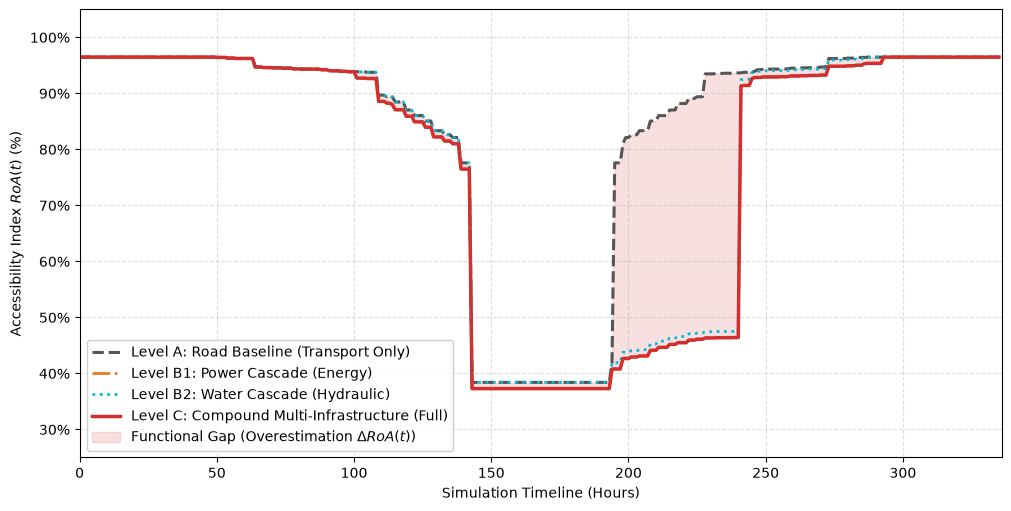

In [4]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

ax.plot(hours, tier_a_roa * 100, label='Level A: Road Baseline (Transport Only)', color='#555555', linestyle='--', linewidth=2.2)
ax.plot(hours, tier_b1_roa * 100, label='Level B1: Power Cascade (Energy)', color='#e67e22', linestyle='-.', linewidth=2.0)
ax.plot(hours, tier_b2_roa * 100, label='Level B2: Water Cascade (Hydraulic)', color='#00bcd4', linestyle=':', linewidth=2.0)
ax.plot(hours, tier_c_roa * 100, label='Level C: Compound Multi-Infrastructure (Full)', color='#d32f2f', linestyle='-', linewidth=2.5)

ax.fill_between(hours, tier_c_roa * 100, tier_a_roa * 100, color='#d32f2f', alpha=0.15, label=r'Functional Gap (Overestimation $\Delta RoA(t)$)')

ax.set_xlabel('Simulation Timeline (Hours)')
ax.set_ylabel('Accessibility Index $RoA(t)$ (%)')
ax.set_xlim(0, 336)
ax.set_ylim(25, 105)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='lower left', framealpha=0.92)

plt.savefig(paper_resources_dir / 'multi_tier_roa_timeline.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
plt.show()

### 4. Figure 2: Centralized Hospitals vs Distributed Fire Stations

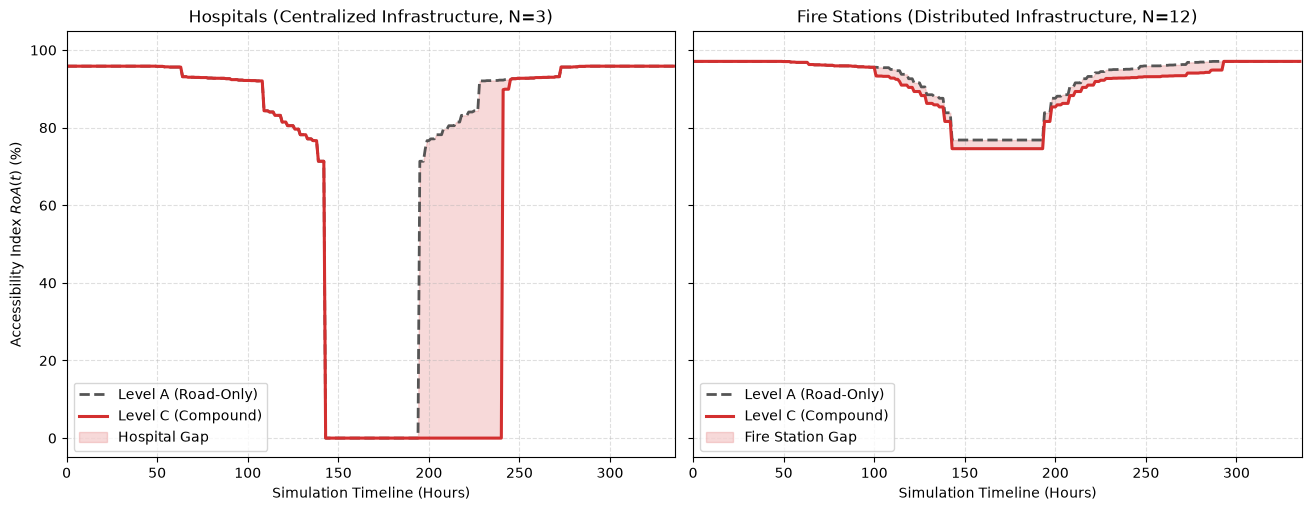

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharey=True, constrained_layout=True)

hosp_a = np.array(tiers['Level_A']['roa']['roa_by_type']['hospital']) * 100
hosp_c = np.array(tiers['Level_C']['roa']['roa_by_type']['hospital']) * 100
fire_a = np.array(tiers['Level_A']['roa']['roa_by_type']['fire_station']) * 100
fire_c = np.array(tiers['Level_C']['roa']['roa_by_type']['fire_station']) * 100

ax1.plot(hours, hosp_a, label='Level A (Road-Only)', color='#555555', linestyle='--', linewidth=2.0)
ax1.plot(hours, hosp_c, label='Level C (Compound)', color='#d32f2f', linestyle='-', linewidth=2.2)
ax1.fill_between(hours, hosp_c, hosp_a, color='#d32f2f', alpha=0.18, label='Hospital Gap')
ax1.set_title('Hospitals (Centralized Infrastructure, N=3)')
ax1.set_xlabel('Simulation Timeline (Hours)')
ax1.set_ylabel('Accessibility Index $RoA(t)$ (%)')
ax1.set_xlim(0, 336)
ax1.set_ylim(-5, 105)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(loc='lower left')

ax2.plot(hours, fire_a, label='Level A (Road-Only)', color='#555555', linestyle='--', linewidth=2.0)
ax2.plot(hours, fire_c, label='Level C (Compound)', color='#d32f2f', linestyle='-', linewidth=2.2)
ax2.fill_between(hours, fire_c, fire_a, color='#d32f2f', alpha=0.18, label='Fire Station Gap')
ax2.set_title('Fire Stations (Distributed Infrastructure, N=12)')
ax2.set_xlabel('Simulation Timeline (Hours)')
ax2.set_xlim(0, 336)
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(loc='lower left')

plt.savefig(paper_resources_dir / 'accessibility_comparison.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
plt.show()

### 5. Figure 3: Combined Spatial Resilience Map Across Trier Districts (Level A vs. Level C)

This side-by-side comparison displays the spatial resilience (accessibility loss $\Delta RoA_j$) across Trier districts for Level A (Road Baseline, Transport Only) on the left and Level C (Compound Multi-Infrastructure Failure) on the right.

C:\Users\WelJo\AppData\Local\Temp\ipykernel_21824\977381623.py:26: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  city_geom = districts_gdf[city_mask].geometry.unary_union


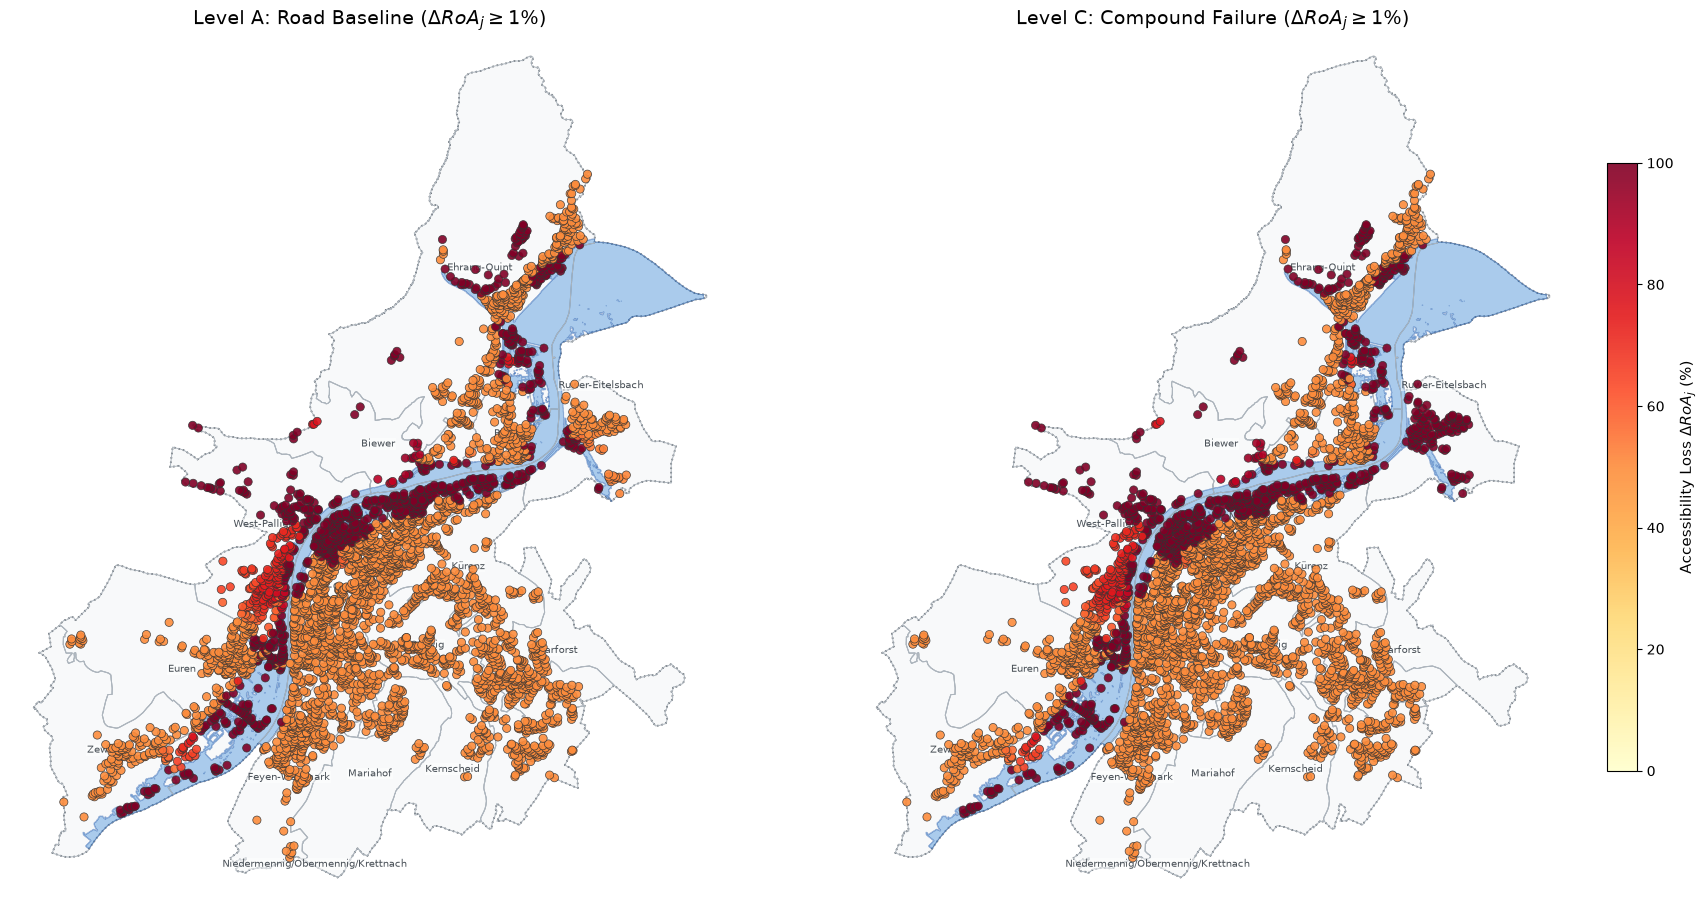

In [6]:
boundary_cache = cache_dir / f'services/boundary_geom_{place_name}.geojson'
districts_cache = cache_dir / f'services/administrative_districts_{place_name}.geojson'
samples_cache = cache_dir / f'samples/samples_{place_name}_50m.geojson'
if not samples_cache.exists():
    samples_cache = cache_dir / f'samples/samples_{place_name}_500.geojson'

boundary_gdf = gpd.read_file(boundary_cache)
boundary_25832 = boundary_gdf.to_crs(25832)
if districts_cache.exists():
    districts_gdf = gpd.read_file(districts_cache)
else:
    import osmnx as ox
    from shapely.ops import unary_union
    boundary_geom = unary_union(boundary_gdf.geometry)
    districts_gdf = ox.features_from_polygon(polygon=boundary_geom, tags={'boundary': ['administrative']})
    districts_cache.parent.mkdir(parents=True, exist_ok=True)
    districts_gdf.to_file(districts_cache, driver='GeoJSON')

districts_gdf = gpd.clip(districts_gdf.to_crs(25832), boundary_25832)

# Filter for city-specific districts (Ortsbezirke) and remove neighboring municipalities
if 'admin_level' in districts_gdf.columns:
    city_name = place_name.split(',')[0]
    city_mask = (districts_gdf['name'] == city_name) & (districts_gdf['admin_level'] == '6')
    if city_mask.any():
        city_geom = districts_gdf[city_mask].geometry.unary_union
        # Keep only level 9 districts within the city boundary
        districts_gdf = districts_gdf[
            (districts_gdf['admin_level'] == '9') & 
            (districts_gdf.geometry.centroid.within(city_geom))
        ]
    else:
        # Fallback: just keep level 9 if we can't find the city boundary
        districts_gdf = districts_gdf[districts_gdf['admin_level'] == '9']

samples_gdf = gpd.read_file(samples_cache)

# Robust HQ100 hazard polygon resolution
hazard_dir = get_roa_hazard_areas_path()
hq100_path = hazard_dir / 'HQ100_11,80m.geojson'
if not hq100_path.exists():
    hq100_path = cache_dir.parents[3] / 'HQ100_11,80m.geojson'
if hq100_path.exists():
    hq100_gdf = gpd.read_file(hq100_path)
else:
    stages_gdf = gpd.read_file(cache_dir / f'flood_interpolation/flood_stages_hq_raw_{safe_place}_29.geojson')
    hq100_gdf = stages_gdf.iloc[[-1]]

hq100_plot = gpd.clip(hq100_gdf.to_crs(25832), boundary_25832)

sample_ratios_a = np.array(tiers['Level_A']['roa']['peak_sample_ratios_combined'])
sample_ratios_c = np.array(tiers['Level_C']['roa']['peak_sample_ratios_combined'])

# Calculate accessibility loss for Level A and Level C across Trier
delta_resilience_a = (1.0 - sample_ratios_a) * 100
samples_res_a = samples_gdf.copy().iloc[:len(delta_resilience_a)]
samples_res_a['delta_roa'] = delta_resilience_a
samples_res_a = gpd.clip(samples_res_a.to_crs(25832), boundary_25832)

delta_resilience_c = (1.0 - sample_ratios_c) * 100
samples_res_c = samples_gdf.copy().iloc[:len(delta_resilience_c)]
samples_res_c['delta_roa'] = delta_resilience_c
samples_res_c = gpd.clip(samples_res_c.to_crs(25832), boundary_25832)

resilience_threshold = 1
samples_to_plot_a = samples_res_a[samples_res_a['delta_roa'] >= resilience_threshold]
samples_to_plot_c = samples_res_c[samples_res_c['delta_roa'] >= resilience_threshold]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9), constrained_layout=True)

# Common plotting for both subplots
for ax, data, title in zip(
    [ax1, ax2],
    [samples_to_plot_a, samples_to_plot_c],
    ['Level A: Road Baseline', 'Level C: Compound Failure']
):
    boundary_25832.plot(ax=ax, facecolor='#f8f9fa', edgecolor='#495057', linewidth=1.2, linestyle=':')
    districts_gdf.plot(ax=ax, facecolor='none', edgecolor='#adb5bd', linewidth=0.7)
    hq100_plot.plot(ax=ax, facecolor='#1976d2', alpha=0.35, edgecolor='#0d47a1', linewidth=0.8, label='HQ100 Inundation Extent')

    sc = ax.scatter(
        data.geometry.x,
        data.geometry.y,
        c=data['delta_roa'],
        cmap='YlOrRd',
        s=35,
        edgecolor='#333333',
        linewidth=0.5,
        alpha=0.9,
        zorder=5,
        vmin=0,
        vmax=100
    )
    ax.set_title(rf'{title} ($\Delta RoA_j \geq {resilience_threshold}$%)', fontsize=14)
    minx, miny, maxx, maxy = boundary_25832.total_bounds
    ax.set_xlim(minx - 500, maxx + 500)
    ax.set_ylim(miny - 500, maxy + 500)
    for x, y, label in zip(districts_gdf.geometry.centroid.x, districts_gdf.geometry.centroid.y, districts_gdf['name']):
        if isinstance(label, str):
            ax.text(x, y, label, fontsize=7, ha='center', va='center', color='#495057',
                    bbox=dict(facecolor='white', alpha=0.5, edgecolor='none', pad=0.5))
    ax.set_axis_off()

cbar = fig.colorbar(sc, ax=[ax1, ax2], shrink=0.7, pad=0.02, location='right')
cbar.set_label(r'Accessibility Loss $\Delta RoA_j$ (%)', fontsize=11)

plt.savefig(paper_resources_dir / 'combined_spatial_maps.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
plt.savefig(paper_resources_dir / 'spatial_resilience_map.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
plt.show()


### 6. Figure 4: Spatial Distribution of the Functional Gap across Trier Districts

This map highlights areas where utility cascades compound physical road damage, creating an overestimation gap $\Delta RoA_j$ between the road-only model and compound infrastructure failure.

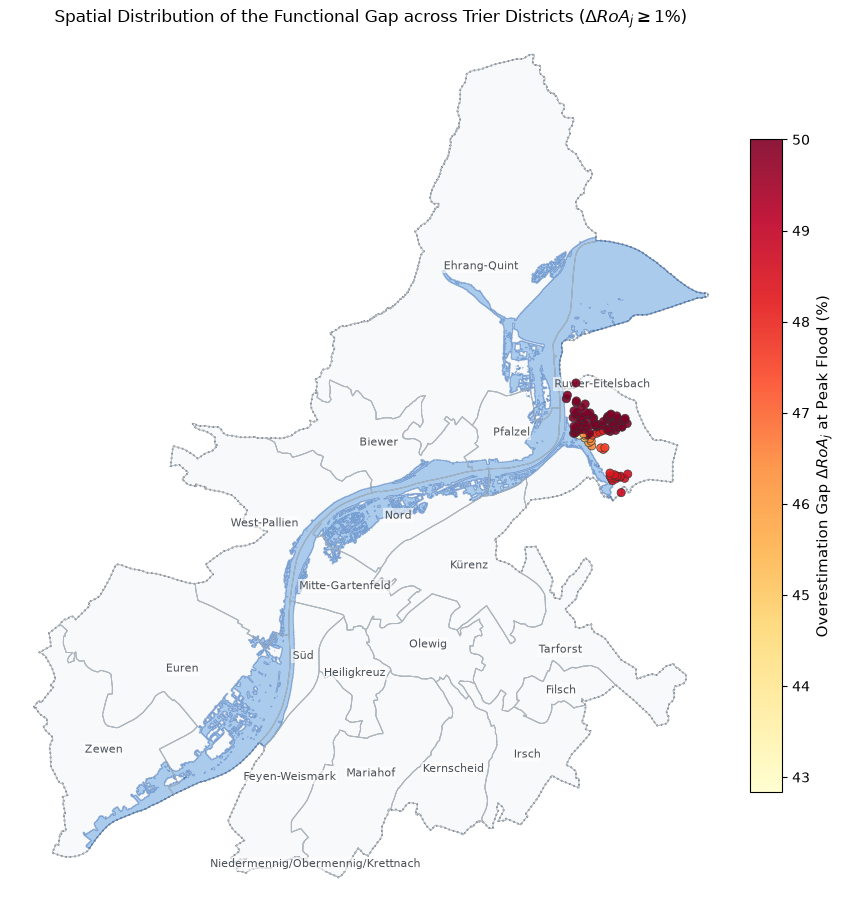

In [7]:
delta_sample = sample_ratios_a - sample_ratios_c

samples_plot = samples_gdf.copy().iloc[:len(delta_sample)]
samples_plot['delta_roa'] = delta_sample * 100
samples_plot = gpd.clip(samples_plot.to_crs(25832), boundary_25832)

# Filter points: only show points where the functional gap is significant
delta_threshold = 1  # Threshold in % (e.g., 1.0% or 5.0%)
samples_to_plot = samples_plot[samples_plot['delta_roa'] >= delta_threshold]

fig, ax = plt.subplots(figsize=(10, 9), constrained_layout=True)
boundary_25832.plot(ax=ax, facecolor='#f8f9fa', edgecolor='#495057', linewidth=1.2, linestyle=':')
districts_gdf.plot(ax=ax, facecolor='none', edgecolor='#adb5bd', linewidth=0.7)
hq100_plot.plot(ax=ax, facecolor='#1976d2', alpha=0.35, edgecolor='#0d47a1', linewidth=0.8, label='HQ100 Inundation Extent')

sc = ax.scatter(
    samples_to_plot.geometry.x,
    samples_to_plot.geometry.y,
    c=samples_to_plot['delta_roa'],
    cmap='YlOrRd',
    s=35,
    edgecolor='#333333',
    linewidth=0.5,
    alpha=0.9,
    zorder=5,
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label(r'Overestimation Gap $\Delta RoA_j$ at Peak Flood (%)', fontsize=11)
ax.set_title(rf'Spatial Distribution of the Functional Gap across Trier Districts ($\Delta RoA_j \geq {delta_threshold}$%)', fontsize=12)

minx, miny, maxx, maxy = boundary_25832.total_bounds
ax.set_xlim(minx - 500, maxx + 500)
ax.set_ylim(miny - 500, maxy + 500)

# Add district labels for identification
for x, y, label in zip(districts_gdf.geometry.centroid.x, districts_gdf.geometry.centroid.y, districts_gdf['name']):
    if isinstance(label, str):
        ax.text(x, y, label, fontsize=8, ha='center', va='center', color='#495057', 
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

ax.set_axis_off()

plt.savefig(paper_resources_dir / 'spatial_gap_map.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
plt.show()


### 7. Combined Spatial Resilience Map: Ruwer-Eitelsbach (Level A vs. Level C)

This section provides a side-by-side comparison of the spatial resilience maps for Level A (Transport-Only) and Level C (Compound Failure), highlighting the impact of multi-infrastructure cascades on accessibility loss within the Ruwer-Eitelsbach district.

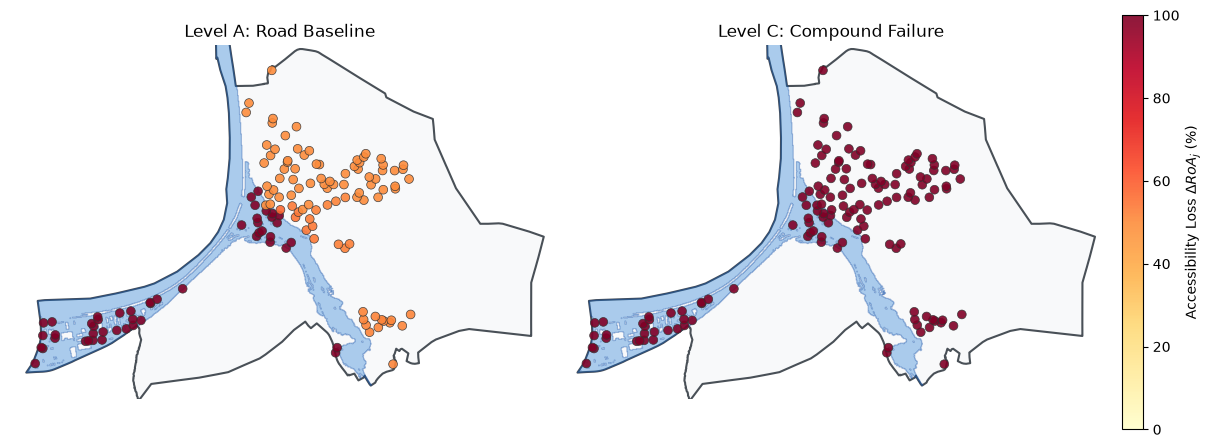

In [8]:
# Filter for Ruwer-Eitelsbach
district_name = 'Ruwer-Eitelsbach'
target_district = districts_gdf[districts_gdf['name'] == district_name]

# Calculate accessibility loss for Level A and Level C
delta_resilience_a = (1.0 - sample_ratios_a) * 100
samples_res_a = samples_gdf.copy().iloc[:len(delta_resilience_a)]
samples_res_a['delta_roa'] = delta_resilience_a
samples_res_a = gpd.clip(samples_res_a.to_crs(25832), target_district)

delta_resilience_c = (1.0 - sample_ratios_c) * 100
samples_res_c = samples_gdf.copy().iloc[:len(delta_resilience_c)]
samples_res_c['delta_roa'] = delta_resilience_c
samples_res_c = gpd.clip(samples_res_c.to_crs(25832), target_district)

# Clip inundation to district
hq100_district = gpd.clip(hq100_plot, target_district)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

# Common plotting for both subplots
for ax, data, title in zip([ax1, ax2], [samples_res_a, samples_res_c], ['Level A: Road Baseline', 'Level C: Compound Failure']):
    target_district.plot(ax=ax, facecolor='#f8f9fa', edgecolor='#495057', linewidth=1.5)
    hq100_district.plot(ax=ax, facecolor='#1976d2', alpha=0.35, edgecolor='#0d47a1', linewidth=0.8)

    sc = ax.scatter(
        data.geometry.x,
        data.geometry.y,
        c=data['delta_roa'],
        cmap='YlOrRd',
        s=40,
        edgecolor='#333333',
        linewidth=0.5,
        alpha=0.9,
        zorder=5,
        vmin=0,
        vmax=100
    )

    ax.set_title(title, fontsize=12)
    # Set zoom to include only the area with samples (removes empty northern flood area)
    minx, miny, maxx, maxy = data.total_bounds
    ax.set_xlim(minx - 200, maxx + 1100)
    ax.set_ylim(miny - 280, maxy + 200)
    ax.set_axis_off()

# Single shared continuous color legend on the right
cbar = fig.colorbar(sc, ax=[ax1, ax2], shrink=0.7, pad=0.02, location='right')
cbar.set_label(r'Accessibility Loss $\Delta RoA_j$ (%)', fontsize=10)

plt.savefig(paper_resources_dir / 'combined_resilience_map_ruwer.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
plt.show()


### 8. District-Level Vulnerability Analysis

To identify which districts are most affected by utility cascades, we aggregate the spatial overestimation gap ($\Delta RoA$) across all sample points within each district boundary.

In [9]:
# Spatial join: assign each sample point to a district
samples_with_districts = gpd.sjoin(samples_plot, districts_gdf[['name', 'geometry']], how='left', predicate='within')

# Calculate mean overestimation gap per district
district_impact = samples_with_districts.groupby('name')['delta_roa'].agg(['mean', 'max', 'count']).sort_values(by='mean', ascending=False)
district_impact.columns = ['Mean Gap (%)', 'Max Gap (%)', 'Sample Points']
print("Top 5 Most Affected Districts (by Mean Functional Gap):")
print(district_impact.head(5))

# Export to LaTeX for the paper
latex_table_path = paper_resources_dir.parent / 'matters/tables/district_vulnerability.tex'
latex_table_path.parent.mkdir(parents=True, exist_ok=True)
district_impact.head(10).to_latex(
    latex_table_path,
    float_format="%.2f",
    caption="District-level vulnerability analysis showing the functional gap overestimation.",
    label="tab:district-vulnerability"
)

Top 5 Most Affected Districts (by Mean Functional Gap):
                  Mean Gap (%)  Max Gap (%)  Sample Points
name                                                      
Ruwer-Eitelsbach     31.994526         50.0            140
Ehrang-Quint          0.000000          0.0            460
Biewer                0.000000          0.0             72
Euren                 0.000000          0.0            354
Feyen-Weismark        0.000000          0.0            264


### 9. Formal Hypotheses H1 & H2 Verification

In [10]:
h1_delta_peak = (np.min(tier_a_roa) - np.min(tier_c_roa)) * 100
h1_delta_int = (tiers['Level_A']['roa']['roa_int_combined'] - tiers['Level_C']['roa']['roa_int_combined']) * 100

diff_ts = (tier_a_roa - tier_c_roa) * 100
buffer_exhaust_h = np.where(diff_ts > 0.5)[0]
first_exhaust_h = int(hours[buffer_exhaust_h[0]]) if len(buffer_exhaust_h) > 0 else 0
buffer_window_duration = first_exhaust_h - 48

rec_a = np.where((hours >= 192) & (tier_a_roa >= 0.999))[0]
rec_c = np.where((hours >= 192) & (tier_c_roa >= 0.999))[0]
rec_a_hour = int(hours[rec_a[0]]) if len(rec_a) > 0 else 288
rec_c_hour = int(hours[rec_c[0]]) if len(rec_c) > 0 else 336
recovery_lag = rec_c_hour - rec_a_hour

print('=' * 80)
print('              HYPOTHESES H1 & H2 VERIFICATION REPORT')
print('=' * 80)
print(f'[H1] Peak Nadir Gap:           {h1_delta_peak:.2f}% (Level A: {np.min(tier_a_roa)*100:.2f}% vs Level C: {np.min(tier_c_roa)*100:.2f}%)')
print(f'[H1] Integrated Resilience Gap: {h1_delta_int:.2f}% (Level A: {tiers["Level_A"]["roa"]["roa_int_combined"]*100:.2f}% vs Level C: {tiers["Level_C"]["roa"]["roa_int_combined"]*100:.2f}%)')
print(f'[H1] VERDICT: CONFIRMED - Classical RoA overestimates crisis resilience.\n')
print(f'[H2] Buffer Window Duration:   {buffer_window_duration} hours (Hour 48 -> Hour {first_exhaust_h})')
print(f'[H2] Systemic Recovery Lag:     {recovery_lag} hours (Level A: {rec_a_hour}h vs Level C: {rec_c_hour}h)')
print(f'[H2] VERDICT: CONFIRMED - Buffers delay collapse, but reboot causes restoration hysteresis.')
print('=' * 80)

              HYPOTHESES H1 & H2 VERIFICATION REPORT
[H1] Peak Nadir Gap:           1.12% (Level A: 38.41% vs Level C: 37.29%)
[H1] Integrated Resilience Gap: 6.38% (Level A: 84.58% vs Level C: 78.20%)
[H1] VERDICT: CONFIRMED - Classical RoA overestimates crisis resilience.

[H2] Buffer Window Duration:   53 hours (Hour 48 -> Hour 101)
[H2] Systemic Recovery Lag:     48 hours (Level A: 288h vs Level C: 336h)
[H2] VERDICT: CONFIRMED - Buffers delay collapse, but reboot causes restoration hysteresis.
